In [1]:
import os 
import scipy.ndimage as ndi
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd 

## Data preprocessing

In [51]:
#open files
base_dir = '../data/test'
imdir = os.path.join(base_dir, 'img')
maskdir = os.path.join(base_dir, 'mask')

In [52]:
#choose your batch
img_index = 251
impath = os.path.join(imdir, f"{img_index}.JPG")
maskpath = os.path.join(maskdir, f"binary_{img_index}.tif")

In [53]:
#load the image and the mask
img = Image.open(impath).convert('RGB')
mask = Image.open(maskpath).convert('L')

In [54]:
#convert the image and the mask
im_arr = np.array(img)
mask_arr = np.array(mask)
sX, sY, C = im_arr.shape #width*height*channel(RGB)
sx, sy = mask_arr.shape #width*height
print("Input image dimension: {0} x {1} x {2}".format(sX,sY,C))
print("Input image dimension: {0} x {1}".format(sx,sy))

Input image dimension: 4000 x 6000 x 3
Input image dimension: 4000 x 6000


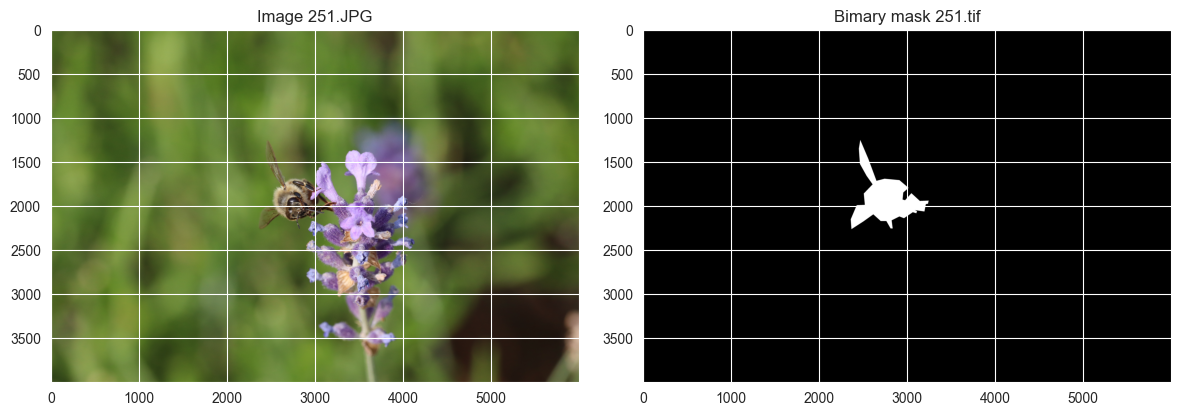

In [55]:
#display image and mmask 
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].imshow(im_arr)
axs[0].set_title(f"Image {img_index}.JPG")
axs[1].imshow(mask_arr, cmap='gray')
axs[1].set_title(f"Bimary mask {img_index}.tif")

plt.tight_layout()


(np.float64(-0.5), np.float64(5999.5), np.float64(3999.5), np.float64(-0.5))

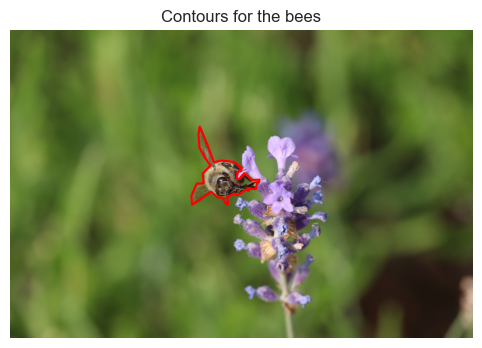

In [56]:
fig, ax = plt.subplots(figsize=(12,4))
ax.imshow(im_arr)
ax.contour(mask_arr, [0.5], colors = 'r');
ax.set_title('Contours for the bees');
ax.axis("off")

In [57]:
mask_bool = mask_arr > 0 #boolean mask i love this for segmentation and bin an image

#the bounding box can be finding via the mask
slices = ndi.find_objects(mask_bool)[0]
y_start, y_stop = slices[0].start, slices[0].stop
x_start, x_stop = slices[1].start, slices[1].stop
bb_width = x_stop - x_start
bb_height = y_stop - y_start

#Draw the bouding box
rect = patches.Rectangle((x_start, y_start), bb_width, bb_height,
                         linewidth=2, edgecolor='red', facecolor='none')
label = "Bee" #let add a tiny cute label

#bouding box ratio
bb_ratio = bb_width / bb_height


(np.float64(-0.5), np.float64(5999.5), np.float64(3999.5), np.float64(-0.5))

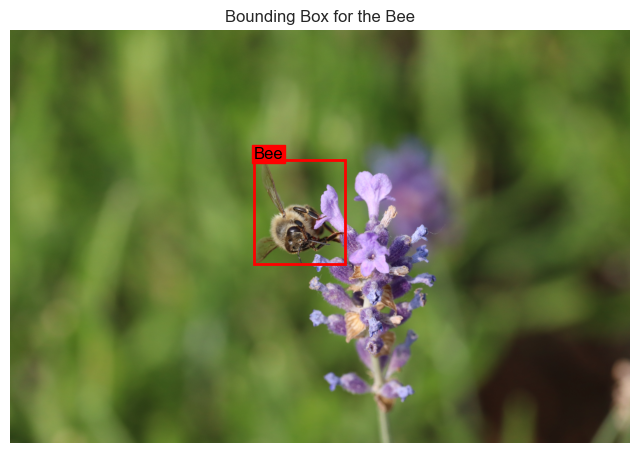

In [58]:
#Display the Bounding Box for bee
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(im_arr)
ax.set_title("Bounding Box for the Bee")
ax.text(x_start, y_start - 10, label, color='black', fontsize=12, bbox=dict(facecolor = 'red',
                                                                          edgecolor='red', boxstyle='square, pad=0.1'))
ax.add_patch(rect)
ax.axis("off")

In [59]:
print(f"Bounding Box X: {x_start}, Y: {y_start}, Width: {bb_width}, Height: {bb_height}")

Bounding Box X: 2356, Y: 1257, Width: 884, Height: 1011


In [60]:
mask_arr

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(4000, 6000), dtype=uint8)

In [61]:
from skimage import measure
import math

In [62]:
contours = measure.find_contours(mask_bool, level=0.5)
print(f"Number of contours found: {len(contours)}")
contour = max(contours, key=lambda c: c.shape[0])
print(f"Selected contour shape: {contour.shape}")
area = np.sum(mask_bool)
perimeter = np.sum(np.sqrt(np.sum(np.diff(contour, axis=0)**2, axis=1)))

Number of contours found: 1
Selected contour shape: (4963, 2)


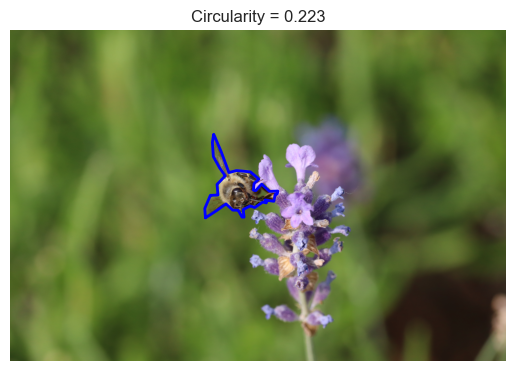

In [63]:
circularity_lp = 4*np.pi * (area / (perimeter ** 2 + 1e-5))
plt.imshow(img)
plt.plot(contour[:, 1], contour[:, 0], color='blue', linewidth=2)
plt.title(f"Circularity = {circularity_lp:.3f}")
plt.axis("off")
plt.show()

## Feature Extraction

In [64]:
#pixel ratio 
bug_p = np.sum(mask_bool)
total = mask_arr.shape[0] * mask_arr.shape[1]
pixel_ratio = bug_p / total

In [65]:
pixel_ratio

np.float64(0.012571333333333334)

In [66]:
features = {}

#RGB statistics 
for i, color in enumerate(['R', 'G', 'B']):
    channel = im_arr[:, :, i]
    values =  channel[mask_bool]
    
    features[f"{color}_min"] = np.min(values)
    features[f"{color}_max"] = np.max(values) 
    features[f"{color}_mean"] = np.mean(values)
    features[f"{color}_median"] = np.median(values)
    features[f"{color}_std"] = np.std(values)

#Shape and symetry
area = bug_p
perimeter = np.sum(np.abs(ndi.laplace(mask_bool.astype(int)) > 0))
cirularity_lp = 4*np.pi * (area / (perimeter ** 2 + 1e-5))
print(f"hey: {circularity_lp}")

#new features
cY, cX = ndi.center_of_mass(mask_bool)

hey: 0.22276651124559382


(np.float64(-0.5), np.float64(5999.5), np.float64(3999.5), np.float64(-0.5))

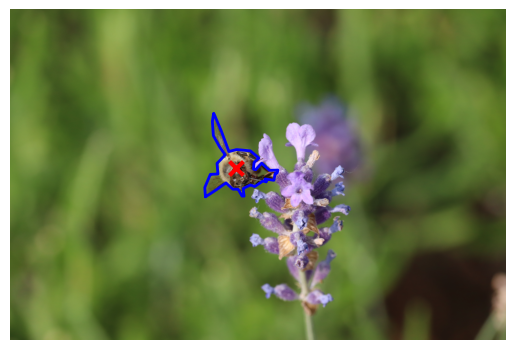

In [67]:
plt.imshow(img)
plt.plot(contour[:, 1], contour[:, 0], color='blue', linewidth=2)
plt.scatter(cX, cY, color='red', s=100, marker='x', label='Center of Mass', linewidths=3)
plt.axis("off")

In [68]:
#all in one dict
features['pixel_ratio'] = pixel_ratio
features['area'] = area 
features['perimeter'] = perimeter
features['circulariy_laplacian'] = cirularity_lp
features['bounding_box_ratio'] = bb_ratio
features['centerMass_x'] = cX 
features['centerMass_y'] = cY

print(f"Features for image {img_index}:")
for key, value in features.items():
    print(f"{key}: {value}")

Features for image 251:
R_min: 5
R_max: 255
R_mean: 112.18455679588482
R_median: 108.0
R_std: 47.170931818496314
G_min: 0
G_max: 255
G_mean: 100.73274182001379
G_median: 104.0
G_std: 47.446011295976376
B_min: 0
B_max: 255
B_mean: 72.33736145728376
B_median: 61.0
B_std: 42.760349593644584
pixel_ratio: 0.012571333333333334
area: 301712
perimeter: 3533
circulariy_laplacian: 0.3037492210475744
bounding_box_ratio: 0.874381800197824
centerMass_x: 2734.6328286577927
centerMass_y: 1915.60590894628


## 250 Mask & Images

In [69]:
def extract_features(img_index, imdir, maskdir):
    try:
        # Chargement fichiers
        impath = os.path.join(imdir, f"{img_index}.JPG")
        maskpath = os.path.join(maskdir, f"binary_{img_index}.tif")

        img = Image.open(impath).convert('RGB')
        mask = Image.open(maskpath).convert('L')

        im_arr = np.array(img)
        mask_arr = np.array(mask)
        mask_bool = mask_arr > 0

        # Pixel ratio
        bug_p = np.sum(mask_bool)
        total = mask_arr.shape[0] * mask_arr.shape[1]
        pixel_ratio = bug_p / total

        # RGB stats
        features = {'ID': img_index}
        for i, color in enumerate(['R', 'G', 'B']):
            channel = im_arr[:, :, i]
            values = channel[mask_bool]
            features[f"{color}_min"] = np.min(values)
            features[f"{color}_max"] = np.max(values)
            features[f"{color}_mean"] = np.mean(values)
            features[f"{color}_median"] = np.median(values)
            features[f"{color}_std"] = np.std(values)

        # Shape & symmetry
        area = bug_p
        perimeter = np.sum(np.abs(ndi.laplace(mask_bool.astype(int)) > 0))
        circularity_lp = 4 * np.pi * (area / (perimeter ** 2 + 1e-5))

        # Bounding box ratio
        slices = ndi.find_objects(mask_bool)[0]
        bb_height = slices[0].stop - slices[0].start
        bb_width = slices[1].stop - slices[1].start
        bb_ratio = bb_width / bb_height

        cY, cX = ndi.center_of_mass(mask_bool)

        features['pixel_ratio'] = pixel_ratio
        features['area'] = area
        features['perimeter'] = perimeter
        features['circularity_laplacian'] = circularity_lp
        features['bounding_box_ratio'] = bb_ratio
        features['center_mass_x'] = cX
        features['center_mass_y'] = cY

        return features

    except Exception as e:
        print(f"Erreur avec l'image {img_index}: {e}")
        return None


In [75]:
bee_or_not = []

for img_idx in range(251, 348):
    feat = extract_features(img_idx, imdir, maskdir)
    if feat is not None:
        bee_or_not.append(feat)

df = pd.DataFrame(bee_or_not)
df.to_csv('bee_features_test.csv', index=False)

print("Fichier CSV 'bee_features_test' généré avec succès.")

Fichier CSV 'bee_features_test' généré avec succès.


In [71]:
#concat the features with the classif.xlsx 

df_features = pd.read_csv('bee_features_test.csv')
df_classif = pd.read_excel('train/classif.xlsx')
df_classif.head(20)

EmptyDataError: No columns to parse from file

In [166]:
df_merged = pd.merge(df_features, df_classif, on='ID')
df_merged.shape

(249, 25)

In [167]:
df_merged.to_csv('bee_features.csv', index=False)